<a href="https://colab.research.google.com/github/alexaK88/Q_jpeg_pennylane/blob/main/full_workflow_fixed_KTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install pennylane

# Full Workflow

This is the complete workflow.

## Import Libraries

In [2]:
import torch
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image
from itertools import product
from collections import Counter
from pennylane import numpy as pnp
from pennylane.templates import QFT
from skimage.transform import resize
from torch.nn.functional import relu
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from pennylane.templates import StronglyEntanglingLayers

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


## Load Data

In [3]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = pnp.concatenate((X_train_full, X_test_full), axis=0)
y = pnp.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(np.uint8) # better to convert for binerization
y = y.astype(np.uint8)

2026-07-07 22:47:06.433095: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
X.shape, y.shape

((70000, 28, 28), (70000,))

## Data Preparation

We restrict the problem to binary classification, because kernel methods usually operate on binary labels (-1, +1).

In [5]:
# focus on binary classification
mask = (y == 0) | (y == 1)

X, y = X[mask], y[mask]

We limit the size of the dataset to `n_samples` because quantum kernel methods scale to approximately O(n^2) and anything more is just too computationally expensive. Also, QJPEG feature extraction is expensive.

In [6]:
n_samples = 300

idx_all = np.arange(len(y))

idx_subset, _ = train_test_split(
    idx_all,
    train_size=n_samples,
    random_state=42,
    stratify=y,
    shuffle=True
)

X = X[idx_subset]
y = y[idx_subset]

Must convert labels to -1 and +1 for kernel methods.

In [7]:
print("Unique labels before encoding:", np.unique(y))
y = np.where(y == 0, -1, 1)
print("Unique labels after encoding:", np.unique(y))

Unique labels before encoding: [0 1]
Unique labels after encoding: [-1  1]


### Image Normalisation

In [8]:
# Normalise pixels
X = X / 255.0
X = X.reshape(-1, 28, 28)

print(X.shape)
print("Pixel range:", X.min(), X.max())

(300, 28, 28)
Pixel range: 0.0 1.0


We reduce each image to 8x8:
8x8 = 64 = 2^6 -> 6 qubits

## Feature Extraction

In [9]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=True,
        preserve_range=True,
        order=1
    )

    vec = img_8x8.flatten().astype(float)

    if vec.sum() == 0:
        vec[0] = 1.0
        return vec

    probs = vec / vec.sum()
    amps = np.sqrt(probs)
    amps = amps / np.linalg.norm(amps)

    return amps

# apply transformation to all images
X_8x8 = pnp.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(300, 64)

###  QJPEG Compression

QJPEG:
- encode image as quantum amplitudes
- apply QFT
- discard qubits: remove high-frequency components
- reconstruct compressed representation

The idea is that we have lower resolution, but the structure is preserved.

In [10]:
def qjpeg_feature_extractor(img, n0, n2, shots):
    """
    Input: single image (28x28)
    Output: feature vector of size (2**n2,)
    """

    Cr, Cc = img.shape
    # --- vectorization ---
    states, norm = vectorization(img, Cr, Cc)

    # --- build circuit ---
    qcs = circuit_builder(states, n0, n2, shots)

    # --- run circuits ---
    out_freq = reconstruction(qcs, n2, norm)  # (num_patches, 2**n2)

    # --- compress patches (IMPORTANT) ---
    features = out_freq.mean(axis=0)  # (2**n2,)
    features = features / np.linalg.norm(features)

    # --- convert to tensor ---
    x = torch.tensor(features, dtype=torch.float32)

    # --- probabilities → amplitudes ---
    x = torch.sqrt(x + 1e-8)

    # --- normalize for amplitude embedding ---
    x = x / (torch.norm(x) + 1e-8)

    return x

def preprocess_for_qjpeg(img):
    img_resized = resize(
        img,
        (16, 16),
        anti_aliasing=True,
        preserve_range=True
    )
    return img_resized

def vectorization(img, Cr, Cc, renorm=False):
    "Vectorize the image into amplitude-encoding patches suitable for quantum circuits"
    # split the original image (Mr, Mc) into S equal-size patches of shape (Cr, Cc)
    Mr, Mc = img.shape
    patches = (img.reshape(Mc//Cr, Cr, -1, Cc).swapaxes(1, 2).reshape(-1, Cr, Cc))
    # 64 patches, (64, 64, 64) shape; S=64

    # vectorize each patch and collect all in a (N, Cr*Cc) array
    vect_patches = np.reshape(patches, (patches.shape[0], Cr * Cc)) # (64, 4096)

    # normalize each (Cr*Cc) vector to the intensity of the corresponding (Cr, Cc) patch
    states = np.zeros((patches.shape[0], Cr * Cc)) # (64, 4096)
    norm = np.zeros(patches.shape[0])

    for idx in range(patches.shape[0]): # for each patch
        # compute the sum of pixels intensities
        norm[idx] = vect_patches[idx].sum()
        if norm[idx] == 0:
            raise ValueError('Pixel value is 0')
        # normalize the patch vector so that its entries sum is 1
        tmp = vect_patches[idx] / norm[idx]
        # take the element-wise square root of the normalized vector
        states[idx] = np.sqrt(tmp)
    if renorm == False:
        norm = np.ones(patches.shape[0])
    # print(states[:10])

    return states, norm # amplitudes, pixek intensities' sums

def qft_swaps(wires):
    n = len(wires)
    # apply QFT to all qubits
    qml.QFT(wires=wires)
    # add swaps to reverse qubit order!
    for i in range(n // 2):
        qml.SWAP(wires=[wires[i], wires[n - i - 1]])


def iqft_swaps(wires):
    n = len(wires)
    # swaps again - BEFORE iqft
    for i in reversed(range(n // 2)):
        qml.SWAP(wires=[wires[i], wires[n-i-1]])
    qml.adjoint(QFT)(wires=wires)

def circuit_builder(states, n0, n2, shots):
    ntilde = (n0 - n2) // 2
    n1 = n0 - ntilde

    qnodes = []

    for idx in range(states.shape[0]):
        # qnode to capture current input state
        @qml.qnode(dev)
        def circuit():
            # print("State norm:", pnp.linalg.norm(states[idx]))
            # initializing the state (using AmplitudeEmbedding here, but I'm wondering if something else could work faster)
            qml.AmplitudeEmbedding(states[idx], wires=range(n0))

            # Hadamard on all n0 qubits
            for w in range(n0):
                qml.Hadamard(wires=w)

            # apply QFT on all qubits
            qft_swaps(wires=range(n0))

            # apply IQFT on first n1 qubits
            iqft_swaps(wires=range(n1))

            # setting boundaries - Rule 2
            discard_start = n0 // 2 - ntilde
            discard_end = n0 // 2 - 1
            discarded_qubits = set(range(discard_start, discard_end + 1))

            measured_qubits = [q for q in range(n1) if q not in discarded_qubits]

            # Hadamard on remaining qubits
            for q in measured_qubits:
                qml.Hadamard(wires=q)

            # print(f'Measured qubits: {measured_qubits}')

            return qml.probs(wires=measured_qubits)
        qnodes.append(circuit)

    return qnodes


def reconstruction(qnodes, n2, norm):
    out_freq = np.zeros((len(qnodes), 2 ** n2))
    for idx, qnode in enumerate(qnodes):
        probs = qnode()  # already a vector of length 2**n2
        # print(f"Circuit {idx} probs:", probs)
        out_freq[idx, :] = probs * norm[idx]
    return out_freq

def devectorization(out_freq):
    S = out_freq.shape[0]
    nrow = int(np.sqrt(out_freq.shape[1])) # rows per patch
    ncol = nrow

    decoded_patches = np.reshape(out_freq, (out_freq.shape[0], nrow, ncol)) # (S, nrow, ncol)

    im_h, im_w = nrow * int(np.sqrt(S)), ncol * int(np.sqrt(S)) # final shape

    # initialization
    decoded_img = np.zeros((im_w, im_h))

    idx = 0
    for row in pnp.arange(im_h - nrow + 1, step=nrow):
        for col in pnp.arange(im_w - ncol + 1, step=ncol):
            decoded_img[row:row+nrow, col:col+ncol] = decoded_patches[idx]
            idx += 1

    return decoded_img

### Train/test Split

In [11]:
idx = pnp.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

In [12]:
n0 = 8  # since 16x16 = 256 = 2^8
n2 = 6  # output dimension = 64 -> matches kernel (4x reduction)
shots = None

# define device with n0 qubits
dev = qml.device("default.qubit", wires=n0, shots=shots)

# extract features
X_train_qjpeg = []
X_test_qjpeg = []

print("Extracting QJPEG features (train)...")
for i in range(len(idx_train)):
    img = preprocess_for_qjpeg(X[idx_train[i]])
    feat = qjpeg_feature_extractor(img, n0=n0, n2=n2, shots=shots)
    X_train_qjpeg.append(feat)

print("Extracting QJPEG features (test)...")
for i in range(len(idx_test)):
    img = preprocess_for_qjpeg(X[idx_test[i]])
    feat = qjpeg_feature_extractor(img, n0=n0, n2=n2, shots=shots)
    X_test_qjpeg.append(feat)

X_train_qjpeg = torch.stack(X_train_qjpeg).float()
X_test_qjpeg  = torch.stack(X_test_qjpeg).float()

Extracting QJPEG features (train)...
Extracting QJPEG features (test)...


In [13]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", pnp.isnan(X_8x8).any())
print("Norm check:", pnp.min(pnp.linalg.norm(X_8x8, axis=1)), pnp.max(pnp.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999999 1.0000000000000002


In [14]:
print("QJPEG NaNs?", torch.isnan(X_train_qjpeg).any())
print("QJPEG norm:",
      torch.min(torch.norm(X_train_qjpeg, dim=1)),
      torch.max(torch.norm(X_train_qjpeg, dim=1)))

QJPEG NaNs? tensor(False)
QJPEG norm: tensor(1.0000) tensor(1.0000)


In [15]:
X_train = X_8x8[idx_train]
X_test  = X_8x8[idx_test]

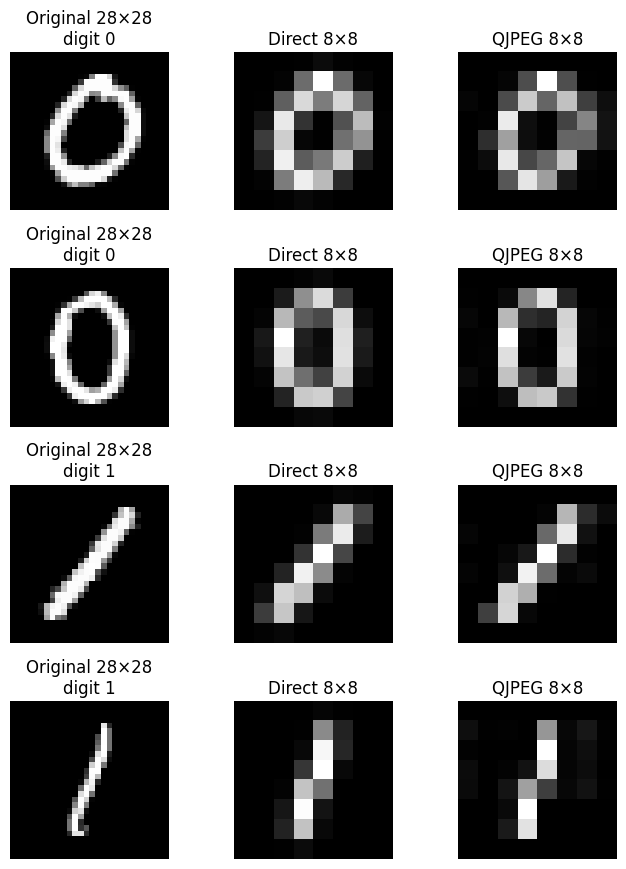

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

def to_numpy(x):
    """Convert torch / PennyLane / numpy object to plain numpy."""
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)

def feature_to_image(feature_vec):
    """
    Convert a 64-dimensional amplitude-like feature vector back to an 8x8 image-like array.

    Both baseline and QJPEG features are amplitude-like vectors,
    so squaring them gives probability/intensity-like values.
    """
    vec = to_numpy(feature_vec).astype(float)
    img = vec.reshape(8, 8) ** 2
    return img

def normalise_for_display(img):
    """Normalise image only for visual display."""
    img = np.array(img, dtype=float)
    if img.max() > img.min():
        return (img - img.min()) / (img.max() - img.min())
    return img

# choose a few examples from the test set
# here: two examples per class, if available
y_test_np = to_numpy(y_test).astype(int)

selected_positions = []
for label in [-1, 1]:
    class_positions = np.where(y_test_np == label)[0]
    selected_positions.extend(class_positions[:2])

n_examples = len(selected_positions)

fig, axes = plt.subplots(
    n_examples,
    3,
    figsize=(7, 2.2 * n_examples)
)

if n_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, pos in enumerate(selected_positions):
    original_img = X[idx_test[pos]]
    direct_img = feature_to_image(X_test[pos])
    qjpeg_img = feature_to_image(X_test_qjpeg[pos])

    label_text = "digit 0" if y_test_np[pos] == -1 else "digit 1"

    images = [
        normalise_for_display(original_img),
        normalise_for_display(direct_img),
        normalise_for_display(qjpeg_img)
    ]

    titles = [
        f"Original 28×28\n{label_text}",
        "Direct 8×8",
        "QJPEG 8×8"
    ]

    for col in range(3):
        axes[row, col].imshow(images[col], cmap="gray")
        axes[row, col].set_title(titles[col])
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("figures/qjpeg_feature_examples.png", dpi=300, bbox_inches="tight")
plt.show()

## QEK definition

In [17]:
n_qubits = 6
dev_ideal = qml.device('default.qubit', wires=n_qubits)

In [18]:
# -----------------------------
# Quantum circuit components
# -----------------------------
def feature_map(x, theta):
    qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=True)

    for l in range(theta.shape[0]):
        for i in range(n_qubits):

            qml.RX(theta[l, i] * 2.0, wires=i)
            qml.RZ(x[i], wires=i)
            qml.RY(theta[l, i] * 2.0, wires=i)

        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i+1) % n_qubits])
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i+2) % n_qubits])

@qml.qnode(dev_ideal, interface="autograd")
def kernel_circuit(x1, x2, theta1, theta2):
    feature_map(x1, theta1)
    qml.adjoint(feature_map)(x2, theta2)
    return qml.probs(wires=range(n_qubits))

def kernel(x1, x2, theta):
    theta1 = theta[0]
    theta2 = theta[1]
    return kernel_circuit(x1, x2, theta1, theta2)[0]

def train_kernel_with_history(
    X,
    y,
    n_qubits,
    n_layers=1,
    steps=100,
    lr=0.02,
    batch_size=8,
    val_size=20,
    seed=42
):
    rng = np.random.RandomState(seed)

    theta = pnp.array(
        rng.normal(0, 0.5, (2, n_layers, n_qubits))
    )

    theta = qml.numpy.array(theta, requires_grad=True)

    opt = qml.GradientDescentOptimizer(lr)
    loss_history = []

    # --- batches ---
    indices = np.arange(len(X))
    rng.shuffle(indices)

    batches = [
        indices[i:i+batch_size]
        for i in range(0, len(indices), batch_size)
    ]

    # --- validation ---
    val_idx = np.random.choice(len(X), size=val_size, replace=False)
    X_val = X[val_idx]
    y_val = y[val_idx]

    print(f"Training with {len(batches)} batches | Validation size = {val_size}")

    # --- TRAIN ---
    for step in range(steps):

        batch = batches[step % len(batches)]
        Xb = X[batch]
        yb = y[batch]

        def cost(theta):

            def kernel_fn(x1, x2):
                return kernel(x1, x2, theta)

            return -qml.kernels.target_alignment(
                Xb, yb,
                kernel_fn,
                assume_normalized_kernel=True
            )

        # update
        theta = opt.step(cost, theta)

        def kernel_fn_val(x1, x2):
            return kernel(x1, x2, theta)

        val_kta = qml.kernels.target_alignment(
            X_val, y_val,
            kernel_fn_val,
            assume_normalized_kernel=True
        )

        loss_history.append(val_kta)

        if step % 10 == 0:
            print(f"Step {step:03d} | Val KTA = {val_kta:.4f}")

    return theta, loss_history

(<Figure size 3500x700 with 1 Axes>, <Axes: >)

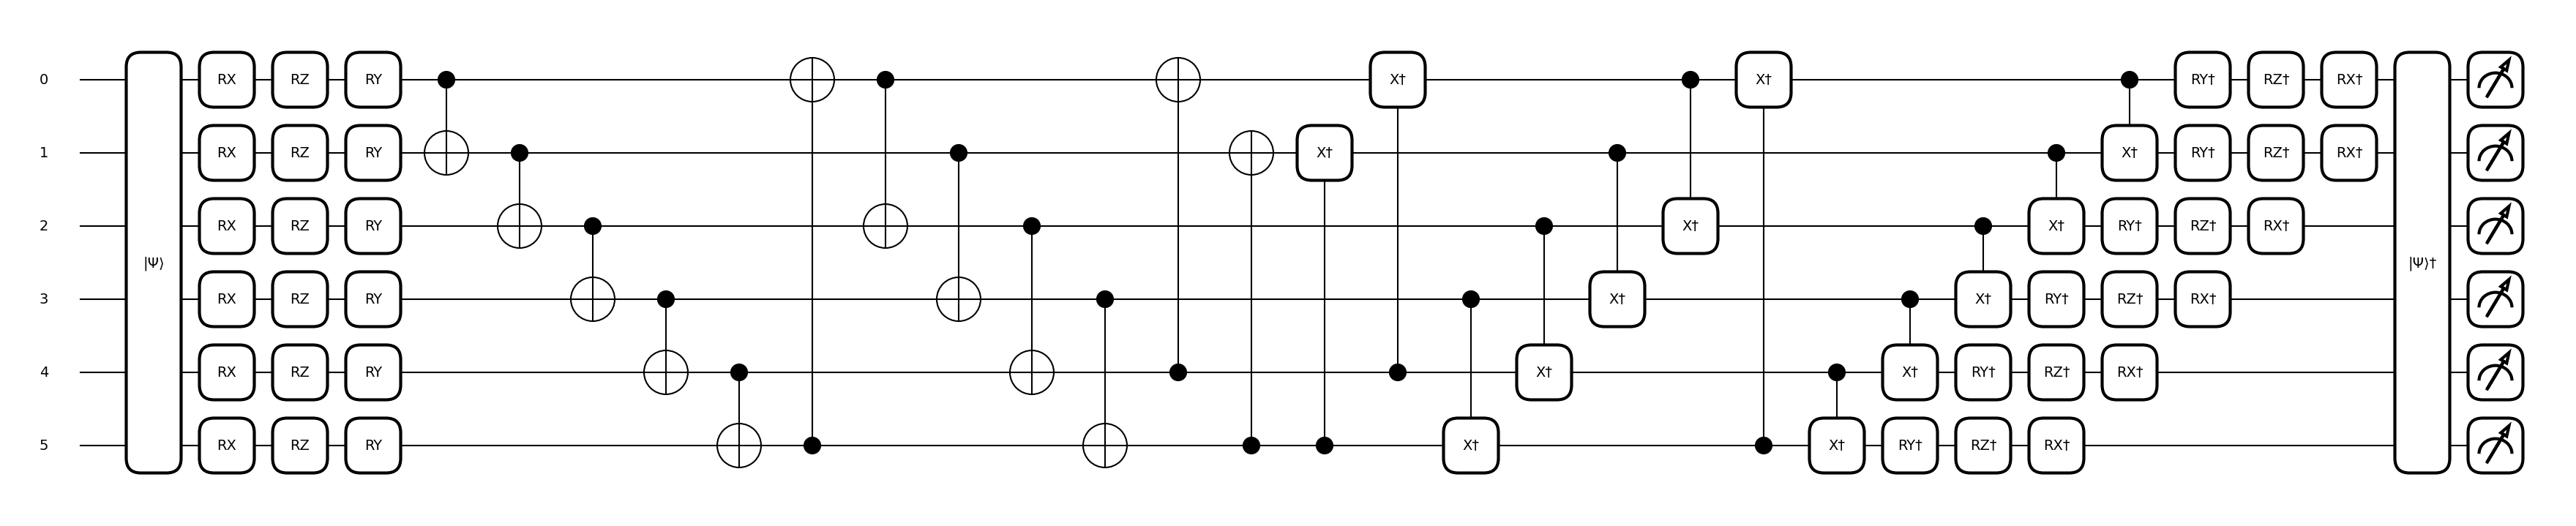

In [19]:
# visualizing the circuit
theta_vis = pnp.array(np.random.normal(0, 0.5, (2, 1, n_qubits)))
qml.draw_mpl(kernel_circuit)(X_train[0], X_train[0], theta_vis[0], theta_vis[1])

## Training Theta

In [20]:
batch_size = 8
steps = 100
lr = 0.01

In [21]:
# --- Ensure all datasets are proper 2D PyTorch tensors ---
import torch
# Convert 8x8 downsampled images
X_train = torch.tensor(pnp.array(X_train), dtype=torch.float32)
X_test  = torch.tensor(pnp.array(X_test), dtype=torch.float32)

# QJPEG features are already tensors, just make sure dtype is float32
X_train_qjpeg = X_train_qjpeg.float()
X_test_qjpeg  = X_test_qjpeg.float()

# Labels should be tensors of type float32
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [22]:
X_train_np = X_train.numpy()
X_test_np  = X_test.numpy()

X_train_qjpeg_np = X_train_qjpeg.detach().numpy()
X_test_qjpeg_np = X_test_qjpeg.detach().numpy()

In [23]:
X_train_np = X_train_np / np.max(np.abs(X_train_np)) * np.pi
X_test_np  = X_test_np  / np.max(np.abs(X_test_np)) * np.pi

X_train_qjpeg_np = X_train_qjpeg_np / np.max(np.abs(X_train_qjpeg_np)) * np.pi
X_test_qjpeg_np  = X_test_qjpeg_np  / np.max(np.abs(X_test_qjpeg_np)) * np.pi

In [24]:
theta_1, loss_history_1 = train_kernel_with_history(
    X_train_np,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=150,
    lr=0.02,
    batch_size=8,
    val_size=20
)

Training with 30 batches | Validation size = 20
Step 000 | Val KTA = 0.2925
Step 010 | Val KTA = 0.2972
Step 020 | Val KTA = 0.3015


/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in arcsin
  return func(*args, **kwargs)


Step 030 | Val KTA = 0.3084
Step 040 | Val KTA = 0.3147
Step 050 | Val KTA = 0.3203
Step 060 | Val KTA = 0.3287
Step 070 | Val KTA = 0.3353
Step 080 | Val KTA = 0.3405
Step 090 | Val KTA = 0.3480
Step 100 | Val KTA = 0.3530
Step 110 | Val KTA = 0.3567
Step 120 | Val KTA = 0.3625
Step 130 | Val KTA = 0.3658
Step 140 | Val KTA = 0.3679


In [25]:
theta_1_qjpeg, loss_history_1_qjpeg = train_kernel_with_history(
    X_train_qjpeg_np,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=150,
    lr=0.02,
    batch_size=8,
    val_size=20
)

Training with 30 batches | Validation size = 20
Step 000 | Val KTA = 0.2071
Step 010 | Val KTA = 0.2101
Step 020 | Val KTA = 0.2130
Step 030 | Val KTA = 0.2143
Step 040 | Val KTA = 0.2151
Step 050 | Val KTA = 0.2164
Step 060 | Val KTA = 0.2169
Step 070 | Val KTA = 0.2172
Step 080 | Val KTA = 0.2179
Step 090 | Val KTA = 0.2183
Step 100 | Val KTA = 0.2184
Step 110 | Val KTA = 0.2189
Step 120 | Val KTA = 0.2192
Step 130 | Val KTA = 0.2192
Step 140 | Val KTA = 0.2197


In [26]:
theta_2, loss_history_2 = train_kernel_with_history(
    X_train_np,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=150,
    lr=0.02,
    batch_size=8,
    val_size=20
)

Training with 30 batches | Validation size = 20
Step 000 | Val KTA = 0.2175
Step 010 | Val KTA = 0.2180
Step 020 | Val KTA = 0.2185
Step 030 | Val KTA = 0.2190
Step 040 | Val KTA = 0.2194
Step 050 | Val KTA = 0.2199
Step 060 | Val KTA = 0.2204
Step 070 | Val KTA = 0.2208
Step 080 | Val KTA = 0.2212
Step 090 | Val KTA = 0.2217
Step 100 | Val KTA = 0.2221
Step 110 | Val KTA = 0.2225
Step 120 | Val KTA = 0.2230
Step 130 | Val KTA = 0.2234
Step 140 | Val KTA = 0.2237


In [27]:
theta_2_qjpeg, loss_history_2_qjpeg = train_kernel_with_history(
    X_train_qjpeg_np,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=150,
    lr=0.02,
    batch_size=8,
    val_size=20
)

Training with 30 batches | Validation size = 20
Step 000 | Val KTA = 0.2178
Step 010 | Val KTA = 0.2181
Step 020 | Val KTA = 0.2184
Step 030 | Val KTA = 0.2187
Step 040 | Val KTA = 0.2190
Step 050 | Val KTA = 0.2193
Step 060 | Val KTA = 0.2196
Step 070 | Val KTA = 0.2199
Step 080 | Val KTA = 0.2202
Step 090 | Val KTA = 0.2205
Step 100 | Val KTA = 0.2207
Step 110 | Val KTA = 0.2210
Step 120 | Val KTA = 0.2213
Step 130 | Val KTA = 0.2216
Step 140 | Val KTA = 0.2218


In [28]:
theta_4, loss_history_4 = train_kernel_with_history(
    X_train_np,
    y_train,
    n_qubits=n_qubits,
    n_layers=4,
    steps=150,
    lr=0.02,
    batch_size=8,
    val_size=20
)

Training with 30 batches | Validation size = 20
Step 000 | Val KTA = 0.2090
Step 010 | Val KTA = 0.2098
Step 020 | Val KTA = 0.2114
Step 030 | Val KTA = 0.2129
Step 040 | Val KTA = 0.2135
Step 050 | Val KTA = 0.2148
Step 060 | Val KTA = 0.2160
Step 070 | Val KTA = 0.2165
Step 080 | Val KTA = 0.2176
Step 090 | Val KTA = 0.2186
Step 100 | Val KTA = 0.2190
Step 110 | Val KTA = 0.2199
Step 120 | Val KTA = 0.2208
Step 130 | Val KTA = 0.2212
Step 140 | Val KTA = 0.2219


In [29]:
theta_4_qjpeg, loss_history_4_qjpeg = train_kernel_with_history(
    X_train_qjpeg_np,
    y_train,
    n_qubits=n_qubits,
    n_layers=4,
    steps=150,
    lr=0.02,
    batch_size=8,
    val_size=20
)

Training with 30 batches | Validation size = 20
Step 000 | Val KTA = 0.2208
Step 010 | Val KTA = 0.2214
Step 020 | Val KTA = 0.2221
Step 030 | Val KTA = 0.2229
Step 040 | Val KTA = 0.2236
Step 050 | Val KTA = 0.2243
Step 060 | Val KTA = 0.2251
Step 070 | Val KTA = 0.2257
Step 080 | Val KTA = 0.2265
Step 090 | Val KTA = 0.2273
Step 100 | Val KTA = 0.2280
Step 110 | Val KTA = 0.2287
Step 120 | Val KTA = 0.2296
Step 130 | Val KTA = 0.2303
Step 140 | Val KTA = 0.2311


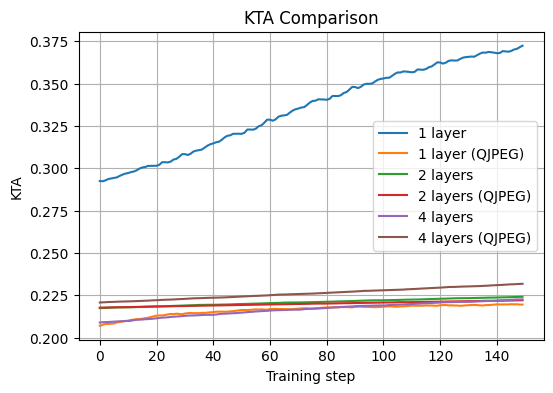

In [40]:
plt.figure(figsize=(6, 4))

plt.plot(loss_history_1, label="1 layer")
plt.plot(loss_history_1_qjpeg, label="1 layer (QJPEG)")
plt.plot(loss_history_2, label="2 layers")
plt.plot(loss_history_2_qjpeg, label="2 layers (QJPEG)")
plt.plot(loss_history_4, label="4 layers")
plt.plot(loss_history_4_qjpeg, label="4 layers (QJPEG)")

plt.xlabel("Training step")
plt.ylabel("KTA")
plt.title("KTA Comparison")

plt.legend()
plt.grid(True)

plt.show()

## Classification

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

y_train_svm = y_train.detach().cpu().numpy().astype(int)
y_test_svm = y_test.detach().cpu().numpy().astype(int)

In [32]:
def compute_train_kernel_matrix(X, theta, name="train"):
    """
    Computes square kernel matrix K_train.
    Shape: (n_train, n_train)
    """
    n = len(X)
    K = np.zeros((n, n))

    for i in range(n):
        if i % 10 == 0:
            print(f"{name}: row {i}/{n}")

        for j in range(i, n):
            value = float(kernel(X[i], X[j], theta))
            K[i, j] = value
            K[j, i] = value

    # numerical cleanup
    K = 0.5 * (K + K.T)
    np.fill_diagonal(K, 1.0)

    return K


def compute_test_kernel_matrix(X_test, X_train, theta, name="test"):
    """
    Computes test kernel matrix.
    Shape: (n_test, n_train)
    """
    n_test = len(X_test)
    n_train = len(X_train)

    K = np.zeros((n_test, n_train))

    for i in range(n_test):
        if i % 10 == 0:
            print(f"{name}: row {i}/{n_test}")

        for j in range(n_train):
            K[i, j] = float(kernel(X_test[i], X_train[j], theta))

    return K

def evaluate_quantum_svm(
    X_train_data,
    X_test_data,
    theta,
    y_train_svm,
    y_test_svm,
    model_name="model"
):
    print(f"\n==============================")
    print(f"Evaluating: {model_name}")
    print(f"==============================")

    # 1. Compute training kernel
    K_train = compute_train_kernel_matrix(
        X_train_data,
        theta,
        name=f"{model_name} train"
    )

    # 2. Train classical SVM
    clf = SVC(kernel="precomputed")
    clf.fit(K_train, y_train_svm)

    # 3. Compute test kernel
    K_test = compute_test_kernel_matrix(
        X_test_data,
        X_train_data,
        theta,
        name=f"{model_name} test"
    )

    # 4. Predict
    y_pred = clf.predict(K_test)

    # 5. Metrics
    acc = accuracy_score(y_test_svm, y_pred)

    print(f"\n{model_name} accuracy:", acc)
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test_svm, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test_svm, y_pred))

    return {
        "model_name": model_name,
        "accuracy": acc,
        "K_train": K_train,
        "K_test": K_test,
        "classifier": clf,
        "y_pred": y_pred
    }

In [33]:
result_1_base = evaluate_quantum_svm(
    X_train_np,
    X_test_np,
    theta_1,
    y_train_svm,
    y_test_svm,
    model_name="1 layer baseline"
)


Evaluating: 1 layer baseline
1 layer baseline train: row 0/240
1 layer baseline train: row 10/240
1 layer baseline train: row 20/240
1 layer baseline train: row 30/240
1 layer baseline train: row 40/240
1 layer baseline train: row 50/240
1 layer baseline train: row 60/240
1 layer baseline train: row 70/240
1 layer baseline train: row 80/240
1 layer baseline train: row 90/240
1 layer baseline train: row 100/240
1 layer baseline train: row 110/240
1 layer baseline train: row 120/240
1 layer baseline train: row 130/240
1 layer baseline train: row 140/240
1 layer baseline train: row 150/240
1 layer baseline train: row 160/240
1 layer baseline train: row 170/240
1 layer baseline train: row 180/240
1 layer baseline train: row 190/240
1 layer baseline train: row 200/240
1 layer baseline train: row 210/240
1 layer baseline train: row 220/240
1 layer baseline train: row 230/240
1 layer baseline test: row 0/60


/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in arcsin
  return func(*args, **kwargs)


1 layer baseline test: row 10/60
1 layer baseline test: row 20/60
1 layer baseline test: row 30/60
1 layer baseline test: row 40/60
1 layer baseline test: row 50/60

1 layer baseline accuracy: 0.9833333333333333

Confusion matrix:
[[28  0]
 [ 1 31]]

Classification report:
              precision    recall  f1-score   support

          -1       0.97      1.00      0.98        28
           1       1.00      0.97      0.98        32

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



In [35]:
result_1_qjpeg = evaluate_quantum_svm(
    X_train_qjpeg_np,
    X_test_qjpeg_np,
    theta_1_qjpeg,
    y_train_svm,
    y_test_svm,
    model_name="1 layer QJPEG"
)


Evaluating: 1 layer QJPEG
1 layer QJPEG train: row 0/240
1 layer QJPEG train: row 10/240
1 layer QJPEG train: row 20/240
1 layer QJPEG train: row 30/240
1 layer QJPEG train: row 40/240
1 layer QJPEG train: row 50/240
1 layer QJPEG train: row 60/240
1 layer QJPEG train: row 70/240
1 layer QJPEG train: row 80/240
1 layer QJPEG train: row 90/240
1 layer QJPEG train: row 100/240
1 layer QJPEG train: row 110/240
1 layer QJPEG train: row 120/240
1 layer QJPEG train: row 130/240
1 layer QJPEG train: row 140/240
1 layer QJPEG train: row 150/240
1 layer QJPEG train: row 160/240
1 layer QJPEG train: row 170/240
1 layer QJPEG train: row 180/240
1 layer QJPEG train: row 190/240
1 layer QJPEG train: row 200/240
1 layer QJPEG train: row 210/240
1 layer QJPEG train: row 220/240
1 layer QJPEG train: row 230/240
1 layer QJPEG test: row 0/60
1 layer QJPEG test: row 10/60
1 layer QJPEG test: row 20/60
1 layer QJPEG test: row 30/60
1 layer QJPEG test: row 40/60
1 layer QJPEG test: row 50/60

1 layer QJPE

In [36]:
result_2_base = evaluate_quantum_svm(
    X_train_np,
    X_test_np,
    theta_2,
    y_train_svm,
    y_test_svm,
    model_name="2 layers baseline"
)


Evaluating: 2 layers baseline
2 layers baseline train: row 0/240


/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in arcsin
  return func(*args, **kwargs)


2 layers baseline train: row 10/240
2 layers baseline train: row 20/240
2 layers baseline train: row 30/240
2 layers baseline train: row 40/240
2 layers baseline train: row 50/240
2 layers baseline train: row 60/240
2 layers baseline train: row 70/240
2 layers baseline train: row 80/240
2 layers baseline train: row 90/240
2 layers baseline train: row 100/240
2 layers baseline train: row 110/240
2 layers baseline train: row 120/240
2 layers baseline train: row 130/240
2 layers baseline train: row 140/240
2 layers baseline train: row 150/240
2 layers baseline train: row 160/240
2 layers baseline train: row 170/240
2 layers baseline train: row 180/240
2 layers baseline train: row 190/240
2 layers baseline train: row 200/240
2 layers baseline train: row 210/240
2 layers baseline train: row 220/240
2 layers baseline train: row 230/240
2 layers baseline test: row 0/60


/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in arcsin
  return func(*args, **kwargs)


2 layers baseline test: row 10/60
2 layers baseline test: row 20/60
2 layers baseline test: row 30/60
2 layers baseline test: row 40/60
2 layers baseline test: row 50/60

2 layers baseline accuracy: 0.7833333333333333

Confusion matrix:
[[22  6]
 [ 7 25]]

Classification report:
              precision    recall  f1-score   support

          -1       0.76      0.79      0.77        28
           1       0.81      0.78      0.79        32

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



In [37]:
result_2_qjpeg = evaluate_quantum_svm(
    X_train_qjpeg_np,
    X_test_qjpeg_np,
    theta_2_qjpeg,
    y_train_svm,
    y_test_svm,
    model_name="2 layers QJPEG"
)


Evaluating: 2 layers QJPEG
2 layers QJPEG train: row 0/240
2 layers QJPEG train: row 10/240
2 layers QJPEG train: row 20/240
2 layers QJPEG train: row 30/240
2 layers QJPEG train: row 40/240
2 layers QJPEG train: row 50/240
2 layers QJPEG train: row 60/240
2 layers QJPEG train: row 70/240
2 layers QJPEG train: row 80/240
2 layers QJPEG train: row 90/240
2 layers QJPEG train: row 100/240
2 layers QJPEG train: row 110/240
2 layers QJPEG train: row 120/240
2 layers QJPEG train: row 130/240
2 layers QJPEG train: row 140/240
2 layers QJPEG train: row 150/240
2 layers QJPEG train: row 160/240
2 layers QJPEG train: row 170/240
2 layers QJPEG train: row 180/240
2 layers QJPEG train: row 190/240
2 layers QJPEG train: row 200/240
2 layers QJPEG train: row 210/240
2 layers QJPEG train: row 220/240
2 layers QJPEG train: row 230/240
2 layers QJPEG test: row 0/60
2 layers QJPEG test: row 10/60
2 layers QJPEG test: row 20/60
2 layers QJPEG test: row 30/60
2 layers QJPEG test: row 40/60
2 layers QJPE

In [38]:
result_4_base = evaluate_quantum_svm(
    X_train_np,
    X_test_np,
    theta_4,
    y_train_svm,
    y_test_svm,
    model_name="4 layers baseline"
)


Evaluating: 4 layers baseline
4 layers baseline train: row 0/240


/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in arcsin
  return func(*args, **kwargs)


4 layers baseline train: row 10/240
4 layers baseline train: row 20/240
4 layers baseline train: row 30/240
4 layers baseline train: row 40/240
4 layers baseline train: row 50/240
4 layers baseline train: row 60/240
4 layers baseline train: row 70/240
4 layers baseline train: row 80/240
4 layers baseline train: row 90/240
4 layers baseline train: row 100/240
4 layers baseline train: row 110/240
4 layers baseline train: row 120/240
4 layers baseline train: row 130/240
4 layers baseline train: row 140/240
4 layers baseline train: row 150/240
4 layers baseline train: row 160/240
4 layers baseline train: row 170/240
4 layers baseline train: row 180/240
4 layers baseline train: row 190/240
4 layers baseline train: row 200/240
4 layers baseline train: row 210/240
4 layers baseline train: row 220/240
4 layers baseline train: row 230/240
4 layers baseline test: row 0/60


/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/autoray/autoray.py:94: RuntimeWarning: invalid value encountered in arcsin
  return func(*args, **kwargs)


4 layers baseline test: row 10/60
4 layers baseline test: row 20/60
4 layers baseline test: row 30/60
4 layers baseline test: row 40/60
4 layers baseline test: row 50/60

4 layers baseline accuracy: 0.6666666666666666

Confusion matrix:
[[12 16]
 [ 4 28]]

Classification report:
              precision    recall  f1-score   support

          -1       0.75      0.43      0.55        28
           1       0.64      0.88      0.74        32

    accuracy                           0.67        60
   macro avg       0.69      0.65      0.64        60
weighted avg       0.69      0.67      0.65        60



In [39]:
result_4_qjpeg = evaluate_quantum_svm(
    X_train_qjpeg_np,
    X_test_qjpeg_np,
    theta_4_qjpeg,
    y_train_svm,
    y_test_svm,
    model_name="4 layers QJPEG"
)


Evaluating: 4 layers QJPEG
4 layers QJPEG train: row 0/240
4 layers QJPEG train: row 10/240
4 layers QJPEG train: row 20/240
4 layers QJPEG train: row 30/240
4 layers QJPEG train: row 40/240
4 layers QJPEG train: row 50/240
4 layers QJPEG train: row 60/240
4 layers QJPEG train: row 70/240
4 layers QJPEG train: row 80/240
4 layers QJPEG train: row 90/240
4 layers QJPEG train: row 100/240
4 layers QJPEG train: row 110/240
4 layers QJPEG train: row 120/240
4 layers QJPEG train: row 130/240
4 layers QJPEG train: row 140/240
4 layers QJPEG train: row 150/240
4 layers QJPEG train: row 160/240
4 layers QJPEG train: row 170/240
4 layers QJPEG train: row 180/240
4 layers QJPEG train: row 190/240
4 layers QJPEG train: row 200/240
4 layers QJPEG train: row 210/240
4 layers QJPEG train: row 220/240
4 layers QJPEG train: row 230/240
4 layers QJPEG test: row 0/60
4 layers QJPEG test: row 10/60
4 layers QJPEG test: row 20/60
4 layers QJPEG test: row 30/60
4 layers QJPEG test: row 40/60
4 layers QJPE

In [41]:
results = [
    result_1_base,
    result_1_qjpeg,
    result_2_base,
    result_2_qjpeg,
    result_4_base,
    result_4_qjpeg
]

import pandas as pd

summary = pd.DataFrame({
    "Model": [r["model_name"] for r in results],
    "Test accuracy": [r["accuracy"] for r in results]
})

summary

,Model,Test accuracy
0,1 layer baseline,0.983333
1,1 layer QJPEG,1.000000
2,2 layers baseline,0.783333
3,2 layers QJPEG,0.683333
4,4 layers baseline,0.666667
5,4 layers QJPEG,0.766667
